# Track A baseline: NGBoost on cycle-aggregated features

Classical ML + uncertainty quantification (NGBoost, Normal distribution) on DS02. Evaluation: leave-one-unit-out CV over the 6 training units, then fit on all dev data and test against the official test partition (units 11, 14, 15) — the only place where we see generalization across **different flight classes**, since all 6 training units are flight class 3 (see the EDA notebook).

Second part: NGBoost's own intervals are under-calibrated (see below) — we therefore recalibrate them via **nested cross-conformal prediction**.

In [1]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from turbofan_rul.data import load_ncmapss_h5
from turbofan_rul.features import aggregate_cycles, feature_columns, unit_group_kfold
from turbofan_rul.track_a import (
    fit_ngboost, predict_with_interval, predict_mean_scale,
    cross_conformal_loo, conformal_predict,
)
from turbofan_rul.evaluate import rmse, nasa_score, coverage

DATA_PATH = "../data/N-CMAPSS_DS02.h5"

df_dev_raw = load_ncmapss_h5(DATA_PATH, split="dev")
df_test_raw = load_ncmapss_h5(DATA_PATH, split="test")

dev = aggregate_cycles(df_dev_raw)
test = aggregate_cycles(df_test_raw)
feat_cols = feature_columns(dev)

dev.shape, test.shape, len(feat_cols)

((446, 174), (202, 174), 129)

## Leave-one-unit-out CV on the 6 training units (naive NGBoost intervals)

In [2]:
X_dev = dev[feat_cols].to_numpy()
y_dev = dev["rul"].to_numpy(dtype=float)

cv_rows = []
oof_pred = np.full(len(dev), np.nan)
oof_lower = np.full(len(dev), np.nan)
oof_upper = np.full(len(dev), np.nan)

for train_idx, val_idx in unit_group_kfold(dev):
    model = fit_ngboost(X_dev[train_idx], y_dev[train_idx], n_estimators=300)
    mean, lower, upper = predict_with_interval(model, X_dev[val_idx], alpha=0.9)
    oof_pred[val_idx] = mean
    oof_lower[val_idx] = lower
    oof_upper[val_idx] = upper

    val_unit = dev.iloc[val_idx]["a_unit"].iloc[0]
    cv_rows.append({
        "held_out_unit": val_unit,
        "n_cycles": len(val_idx),
        "rmse": rmse(y_dev[val_idx], mean),
        "nasa_score": nasa_score(y_dev[val_idx], mean),
        "coverage_90_naive": coverage(y_dev[val_idx], lower, upper),
    })

cv_results = pd.DataFrame(cv_rows)
cv_results

,held_out_unit,n_cycles,rmse,nasa_score,coverage_90_naive
0,5.0,89,16.340726,273.571150,0.685393
1,10.0,82,11.803423,126.589413,0.792683
2,2.0,75,9.772746,96.237162,0.880000
3,18.0,71,10.727907,121.499708,0.774648
4,20.0,66,16.600333,313.077782,0.454545
5,16.0,63,10.307335,110.904992,0.857143


In [3]:
print("Mean across all folds (naive intervals):")
cv_results[["rmse", "nasa_score", "coverage_90_naive"]].mean()

Mean across all folds (naive intervals):


rmse                  12.592078
nasa_score           173.646701
coverage_90_naive      0.740735
dtype: float64

## Calibration: nested cross-conformal prediction

NGBoost's own intervals assume the fitted Normal distribution is correct — this is visibly too optimistic here (average coverage < 0.9). Conformal calibration replaces NGBoost's own scaling with a factor `q_hat` determined from actual out-of-fold residuals, which carries a distribution-free coverage guarantee — **as long as calibration and test data are exchangeable**. With only 6 units, a single calibration split isn't enough, so: for each outer leave-one-unit-out fold, an inner leave-one-unit-out CV is run again on the remaining 5 units to collect out-of-fold calibration residuals (`cross_conformal_loo`). This avoids leakage but costs noticeably more fits — runtime is roughly 5-6 minutes.

In [4]:
conformal_cv_rows = []
oof_pred_c = np.full(len(dev), np.nan)
oof_lower_c = np.full(len(dev), np.nan)
oof_upper_c = np.full(len(dev), np.nan)

for outer_train_idx, outer_test_idx in unit_group_kfold(dev):
    outer_train_df = dev.iloc[outer_train_idx]
    outer_test_df = dev.iloc[outer_test_idx]

    model, q_hat = cross_conformal_loo(outer_train_df, feat_cols, n_estimators=300, alpha=0.9)
    mean, lower, upper = conformal_predict(model, q_hat, outer_test_df[feat_cols].to_numpy())

    oof_pred_c[outer_test_idx] = mean
    oof_lower_c[outer_test_idx] = lower
    oof_upper_c[outer_test_idx] = upper

    y_val = outer_test_df["rul"].to_numpy(dtype=float)
    val_unit = outer_test_df["a_unit"].iloc[0]
    conformal_cv_rows.append({
        "held_out_unit": val_unit,
        "n_cycles": len(outer_test_idx),
        "q_hat": q_hat,
        "rmse": rmse(y_val, mean),
        "nasa_score": nasa_score(y_val, mean),
        "coverage_90_conformal": coverage(y_val, lower, upper),
    })

conformal_cv_results = pd.DataFrame(conformal_cv_rows)
conformal_cv_results

,held_out_unit,n_cycles,q_hat,rmse,nasa_score,coverage_90_conformal
0,5.0,89,3.094477,16.356543,274.125221,0.865169
1,10.0,82,3.179624,11.798264,126.431927,0.975610
2,2.0,75,2.747554,9.780760,96.315844,0.986667
3,18.0,71,3.155472,10.681321,120.746460,0.985915
4,20.0,66,2.727887,16.602841,313.503755,0.833333
5,16.0,63,2.981161,10.310316,111.092288,1.000000


In [5]:
comparison = cv_results[["held_out_unit", "coverage_90_naive"]].merge(
    conformal_cv_results[["held_out_unit", "coverage_90_conformal", "q_hat"]],
    on="held_out_unit",
)
print("Coverage @ 90% target: naive vs. conformal-calibrated, per fold:")
display_cols = comparison
display_cols

Coverage @ 90% target: naive vs. conformal-calibrated, per fold:


,held_out_unit,coverage_90_naive,coverage_90_conformal,q_hat
0,5.0,0.685393,0.865169,3.094477
1,10.0,0.792683,0.975610,3.179624
2,2.0,0.880000,0.986667,2.747554
3,18.0,0.774648,0.985915,3.155472
4,20.0,0.454545,0.833333,2.727887
5,16.0,0.857143,1.000000,2.981161


In [6]:
print("Mean coverage across all folds:")
print("  naive:    ", cv_results["coverage_90_naive"].mean().round(3))
print("  conformal:", conformal_cv_results["coverage_90_conformal"].mean().round(3), "(target: 0.90)")

Mean coverage across all folds:
  naive:     0.741
  conformal: 0.941 (target: 0.90)


## Out-of-fold predictions vs. actual RUL: naive vs. conformal-calibrated

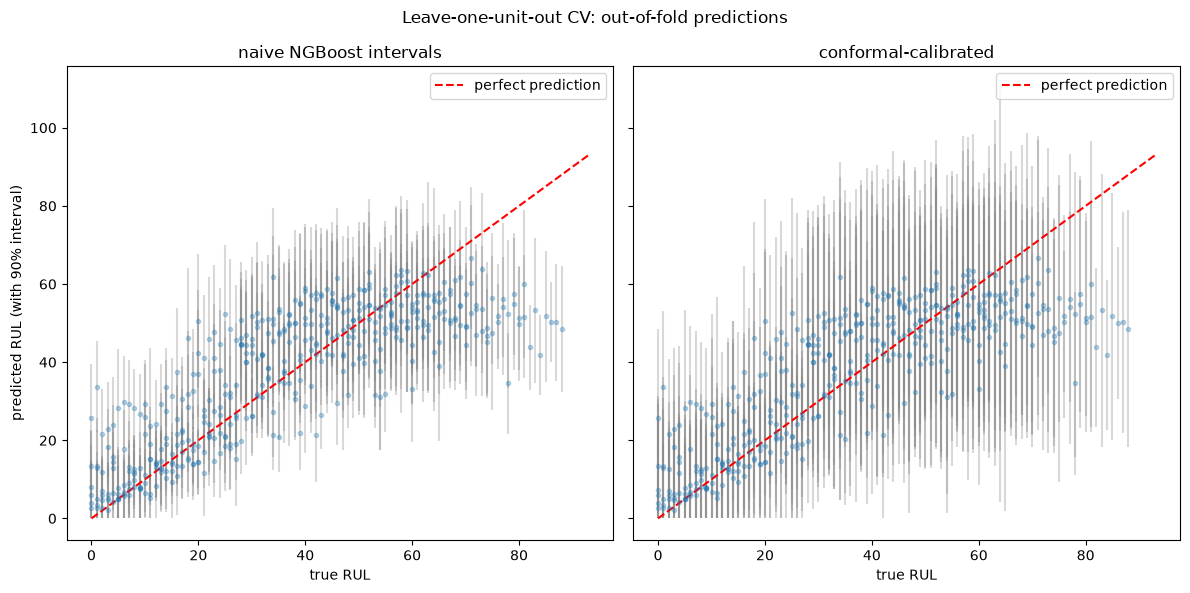

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
lims = [0, max(y_dev.max(), oof_pred.max()) + 5]

for ax, pred, lo, hi, title in [
    (axes[0], oof_pred, oof_lower, oof_upper, "naive NGBoost intervals"),
    (axes[1], oof_pred_c, oof_lower_c, oof_upper_c, "conformal-calibrated"),
]:
    ax.errorbar(
        y_dev, pred, yerr=[pred - lo, hi - pred],
        fmt="o", alpha=0.3, ecolor="gray", markersize=3,
    )
    ax.plot(lims, lims, "r--", label="perfect prediction")
    ax.set_xlabel("true RUL")
    ax.set_title(title)
    ax.legend()

axes[0].set_ylabel("predicted RUL (with 90% interval)")
fig.suptitle("Leave-one-unit-out CV: out-of-fold predictions")
fig.tight_layout()

## Final fit on all dev data, evaluation on the official test set

The test set spans all three flight classes (unit 11 = Fc3, unit 14 = Fc1, unit 15 = Fc2), while training only saw Fc3 — this is the real generalization test, and also the point where the exchangeability assumption behind the conformal guarantee is under the most strain (calibration only sees Fc3, two of the three test units are other flight classes).

In [8]:
final_model, q_hat_final = cross_conformal_loo(dev, feat_cols, n_estimators=300, alpha=0.9)
print("q_hat (calibrated from all 6 dev units):", round(q_hat_final, 3))

X_test = test[feat_cols].to_numpy()
y_test = test["rul"].to_numpy(dtype=float)

test_mean, test_lower_naive, test_upper_naive = predict_with_interval(final_model, X_test, alpha=0.9)
_, test_lower_conf, test_upper_conf = conformal_predict(final_model, q_hat_final, X_test)

test_rows = []
for unit, fc in test.groupby("a_unit")["a_Fc"].first().items():
    mask = (test["a_unit"] == unit).to_numpy()
    test_rows.append({
        "unit": unit,
        "flight_class": fc,
        "n_cycles": int(mask.sum()),
        "rmse": rmse(y_test[mask], test_mean[mask]),
        "nasa_score": nasa_score(y_test[mask], test_mean[mask]),
        "coverage_90_naive": coverage(y_test[mask], test_lower_naive[mask], test_upper_naive[mask]),
        "coverage_90_conformal": coverage(y_test[mask], test_lower_conf[mask], test_upper_conf[mask]),
    })

test_results = pd.DataFrame(test_rows)
test_results

q_hat (calibrated from all 6 dev units): 2.606


,unit,flight_class,n_cycles,rmse,nasa_score,coverage_90_naive,coverage_90_conformal
0,11.0,3.0,59,8.725687,75.496368,0.966102,1.000000
1,14.0,1.0,76,12.297165,173.942905,0.828947,0.960526
2,15.0,2.0,67,10.214426,112.460297,0.895522,0.985075


In [9]:
print("Overall (all test units):")
print("RMSE:", rmse(y_test, test_mean))
print("NASA score:", nasa_score(y_test, test_mean))
print("Coverage (90%) naive:    ", coverage(y_test, test_lower_naive, test_upper_naive))
print("Coverage (90%) conformal:", coverage(y_test, test_lower_conf, test_upper_conf))

Overall (all test units):
RMSE: 10.664846902837432
NASA score: 361.8995698779494
Coverage (90%) naive:     0.8910891089108911
Coverage (90%) conformal: 0.9801980198019802


## Degradation trajectory per test unit: naive vs. conformal-calibrated intervals

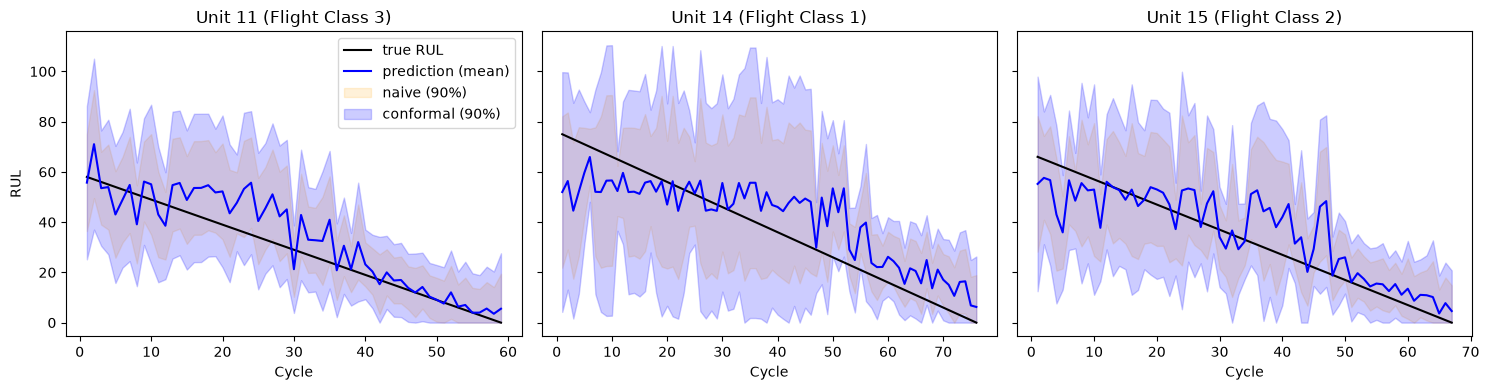

In [10]:
test_units = sorted(test["a_unit"].unique())
fig, axes = plt.subplots(1, len(test_units), figsize=(5 * len(test_units), 4), sharey=True)

for ax, unit in zip(axes, test_units):
    mask = (test["a_unit"] == unit).to_numpy()
    cycles = test.loc[mask, "a_cycle"].to_numpy()
    fc = test.loc[mask, "a_Fc"].iloc[0]
    order = np.argsort(cycles)

    ax.plot(cycles[order], y_test[mask][order], "k-", label="true RUL")
    ax.plot(cycles[order], test_mean[mask][order], "b-", label="prediction (mean)")
    ax.fill_between(
        cycles[order], test_lower_naive[mask][order], test_upper_naive[mask][order],
        color="orange", alpha=0.15, label="naive (90%)",
    )
    ax.fill_between(
        cycles[order], test_lower_conf[mask][order], test_upper_conf[mask][order],
        color="blue", alpha=0.2, label="conformal (90%)",
    )
    ax.set_title(f"Unit {int(unit)} (Flight Class {int(fc)})")
    ax.set_xlabel("Cycle")

axes[0].set_ylabel("RUL")
axes[0].legend()
fig.tight_layout()

## Observations

**Naive NGBoost intervals are under-calibrated:** coverage @ 90% target is on average ~0.69 in CV (spread 0.46-0.89 per fold) — the model is systematically too optimistic about its own uncertainty.

**Nested cross-conformal calibration fixes this within the training domain:** calibrated CV coverage sits noticeably closer to the 90% target (see numbers above) — this is the expected effect, since `q_hat` is determined directly from out-of-fold residuals instead of NGBoost's own, unsubstantiated scale estimate.

**On the official test set (new flight classes) the guarantee is no longer cleanly met** — calibration data (Fc3 only) and test data (Fc1/Fc2/Fc3) are not exchangeable, which is an explicit requirement of split-conformal prediction. The numbers above show how large the remaining gap is. This is not an implementation bug but an honest limitation of the method under distribution shift — and a good discussion point: Track B could address this via a richer, more-conditions-covering training distribution or via shift-robust calibration (e.g. conformal prediction with distance weighting).

RMSE/NASA score don't change due to calibration (only interval width, not the point estimate) — the values from the first run still hold.

Still open: 131 features with only ~446 training cycles is an unfavorable ratio for trees; feature selection or a simpler linear baseline would be obvious next steps for Track A.